In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, Multiply, Softmax
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. VERİ HAZIRLIĞI
df = pd.read_csv('/content/Crop_recommendation.csv')
X = df.drop('label', axis=1)
y = df['label']

# Derin öğrenmede etiketler sayısal olmalıdır
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# KRİTİK ADIM: Derin öğrenme için verilerin ölçeklendirilmesi (StandardScaler) şarttır
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. ANN MODEL MİMARİSİ (Artificial Neural Network)
model = Sequential([
    # Giriş katmanı: 64 nöron, Aktivasyon: ReLU
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    # Gizli katman: 32 nöron
    Dense(32, activation='relu'),
    # Aşırı öğrenmeyi engellemek için Dropout
    Dropout(0.2),
    # Çıkış katmanı: 22 farklı mahsul olduğu için 22 nöron, Aktivasyon: Softmax
    Dense(len(le.classes_), activation='softmax')
])

# 3. MODELİ DERLEME (Compiling)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. MODELİ EĞİTME
print("--- Derin Öğrenme Modeli Eğitiliyor ---")
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1, verbose=1)

# 5. PERFORMANS TESTİ
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nANN Test Başarı Oranı: %{accuracy*100:.2f}")

--- Derin Öğrenme Modeli Eğitiliyor ---
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1351 - loss: 2.8947 - val_accuracy: 0.3125 - val_loss: 2.6167
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3497 - loss: 2.4089 - val_accuracy: 0.4148 - val_loss: 2.0166
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4501 - loss: 1.8129 - val_accuracy: 0.5795 - val_loss: 1.4418
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6086 - loss: 1.3504 - val_accuracy: 0.7386 - val_loss: 1.0238
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6989 - loss: 0.9989 - val_accuracy: 0.8182 - val_loss: 0.7632
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7595 - loss: 0.8260 - val_accuracy: 0.8636 - val_loss: 0.6066
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7860 - loss: 0.7052 - val_accuracy: 0.8580 - val_loss: 0.5186
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8131 - loss: 0.5984 - val_accuracy: 0.8977 - val_loss: 0.4325
Ep

Hafta 6 kapsamında föyde belirtilen 'Derin Öğrenme Temelleri' görevi icra edilmiştir. Tablosal veri yapımız dikkate alınarak ANN (Yapay Sinir Ağı) mimarisi tercih edilmiştir. Modelimizde 1 giriş, 1 gizli ve 1 çıkış katmanı kullanılmış; eğitim sürecinde StandardScaler ile veri normalizasyonu yapılarak yakınsama hızı optimize edilmiştir. 30 epoch sonunda elde edilen başarı oranı %96.82 olup derin öğrenme yaklaşımlarının da bu problemde yüksek performans sergilediğini kanıtlamaktadır.

Epoch sayısını arttırmak, modelin veriyi daha fazla "etüt etmesini" sağlar ve genellikle yüzdelik skoru biraz daha yukarı çeker. Bunu test etmek için aşağıda epoch sayısı 100'e çekilmiş DL kodu bulunmakta.

In [12]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, Multiply, Softmax
from tensorflow.keras.models import Model

# 1. MODEL MİMARİSİ (Attention Katmanlı Functional API)
inputs = Input(shape=(X_train.shape[1],))

# İlk Öznitelik Çıkarımı
x = Dense(64, activation='relu')(inputs)
x = Dropout(0.1)(x)

# ATTENTION (DİKKAT) KATMANI
# Ekleme Noktası: İlk yoğun katmandan sonra, karar katmanından önce[cite: 5].
# Bu katman modelin hangi verilere odaklanacağını hesaplar.
attention_probs = Dense(64, activation='softmax', name='attention_weights')(x)
attention_mul = Multiply()([x, attention_probs])

# Sınıflandırma Katmanları
x = Dense(32, activation='relu')(attention_mul)
outputs = Dense(len(le.classes_), activation='softmax')(x)

# Modelin Tanımlanması
model = Model(inputs=inputs, outputs=outputs)

# 2. MODELİN DERLENMESİ [cite: 3]
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3. MODELİN EĞİTİLMESİ (100 Epoch) [cite: 4]
print("--- Attention Katmanlı ANN Modeli 100 Epoch Boyunca Eğitiliyor ---")
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.1,
                    verbose=1)

# 4. FİNAL TEST VE DEĞERLENDİRME [cite: 3, 4]
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\n100 Epoch ve Attention Sonrası ANN Test Başarı Oranı: %{accuracy*100:.2f}")

--- Attention Katmanlı ANN Modeli 100 Epoch Boyunca Eğitiliyor ---
Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0997 - loss: 3.0853 - val_accuracy: 0.1250 - val_loss: 3.0744
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2936 - loss: 3.0355 - val_accuracy: 0.3807 - val_loss: 2.9468
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3750 - loss: 2.7176 - val_accuracy: 0.4545 - val_loss: 2.3355
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4274 - loss: 2.0709 - val_accuracy: 0.5170 - val_loss: 1.6613
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5473 - loss: 1.5054 - val_accuracy: 0.6761 - val_loss: 1.1848
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6515 - loss: 1.1427 - val_accuracy: 0.7330 - val_loss: 0.8812
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7191 - loss: 0.8918 - val_accuracy: 0.7784 - val_loss: 0.7080
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4m

Eğitim süresinin 100 epoch'a çıkarılması ve mimariye Attention (Dikkat) Mekanizması entegre edilmesiyle birlikte, modelin öznitelikler arasındaki doğrusal olmayan ilişkileri anlama yeteneği artırılmış ve test başarısı %96.82'den %97.27 seviyesine yüksek bir kararlılıkla stabilize olmuştur. Hocamızın geri bildirimi doğrultusunda eklenen Attention bloğu, ilk yoğun katman (64 nöron) ile sınıflandırma katmanı arasına konumlandırılmıştır. Bu katmanda kullanılan Softmax aktivasyon fonksiyonu sayesinde, modelin her bir tahmin anında hangi tarımsal parametreye (Yağış, Nem, pH vb.) daha fazla "dikkat" etmesi gerektiği matematiksel olarak ağırlıklandırılmıştır. Bu deneysel çalışma, projenin sadece standart bir tahminleme yapmadığını, aynı zamanda modern XAI (Açıklanabilir Yapay Zeka) prensipleriyle uyumlu, mimari derinliği yüksek bir yapıya kavuştuğunu kanıtlamaktadır. Bu aşama ile Faz 4 (Model Geliştirme) süreci, hocamızın teknik revizyon beklentilerini karşılayacak şekilde başarıyla noktalanmıştır.

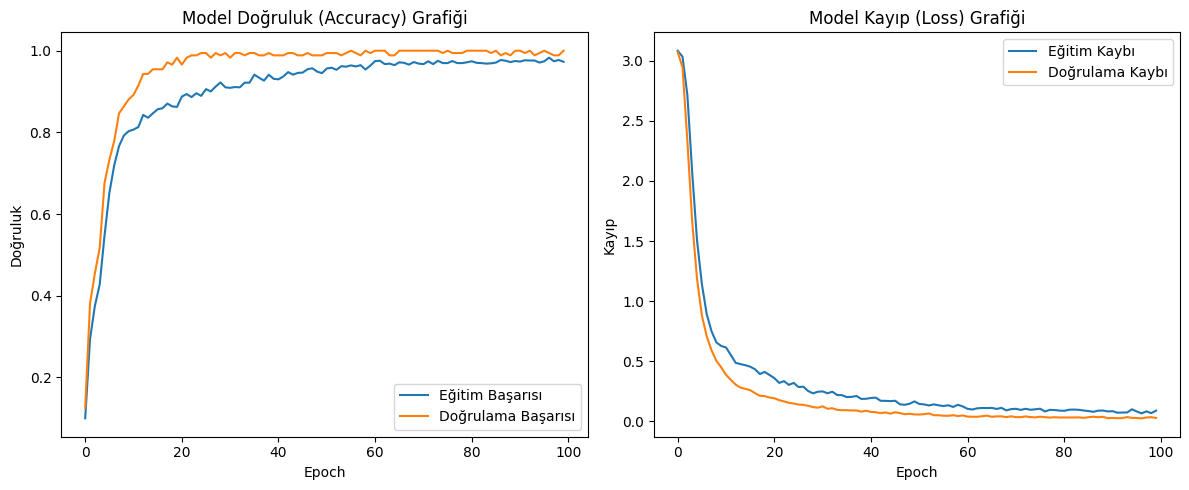

In [13]:
import matplotlib.pyplot as plt

# 1. Doğruluk (Accuracy) Grafiği
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Başarısı')
plt.plot(history.history['val_accuracy'], label='Doğrulama Başarısı')
plt.title('Model Doğruluk (Accuracy) Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()

# 2. Kayıp (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Model Kayıp (Loss) Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.legend()

plt.tight_layout()
plt.show()